In [1]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
import csv
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [2]:
#General Parameters for improve results 

alpha =0.5   # Bell curve coefficient 
dropout = 0.0       #deactivation of neuron = for now 0 , little data set
Lambda = 0.5 # how much to weight the loss of physics
epochs = 600
seed=42
patience = 100        
batch_size=16
CHECK = ['Torque'] # Which Formula to use for loss 

In [3]:
#import Excel Data

notebook_dir = os.getcwd() #where is file located
file_path =os.path.join(notebook_dir,'Data','MLPartAB.xlsx') #Read the file 

#read Excel with formulas using Openpyxl

wb = pxl.load_workbook(file_path) #create local data
ws = wb.active 

headers = [ws.cell(1,col).value for col in range (1,ws.max_column+1)]

#Convert excel language to python

#extract names
letter_to_name = {}
for col in range(1,ws.max_column+1):
    letter = pxl.utils.get_column_letter(col)
    letter_to_name[letter] =headers[col-1]

def excel_to_python(formula, letter_to_name):
    result = formula
    result = result.lstrip('=')
    result = result.replace('$', '')
    result = re.sub(r'\bPI\(\)', 'np.pi', result)

    def replace_ref(match):
        letter = match.group(1)
        if letter in letter_to_name:
            name = letter_to_name[letter]
            return f"df['{name}']"
        return match.group(0)

    result = re.sub(r'\b([A-Z]{1,3})(\d+)\b', replace_ref, result)
    #extract the formulas
    excel_to_np = {
        'SIN'   : 'np.sin',
        'COS'   : 'np.cos',
        'TAN'   : 'np.tan',
        'ATAN'  : 'np.arctan',
        'ATAN2' : 'np.arctan2',
        'ASIN'  : 'np.arcsin',
        'ACOS'  : 'np.arccos',
        'SQRT'  : 'np.sqrt',
        'ABS'   : 'np.abs',
        'EXP'   : 'np.exp',
        'LOG'   : 'np.log',
        'LOG10' : 'np.log10',
        'POWER' : 'np.power',
        'MOD'   : 'np.mod',
        'FLOOR' : 'np.floor',
        'CEIL'  : 'np.ceil',
        'ROUND' : 'np.round',
        'MAX'   : 'np.maximum',
        'MIN'   : 'np.minimum',
        'SUM'   : 'np.sum',
    }

    for excel_fn, np_fn in excel_to_np.items():
        result = re.sub(rf'\b{excel_fn}\b', np_fn, result)

    result = result.replace('^', '**')
    result = result.lstrip('=')

    return result

#create a formula list

formula_list = {}
for col in range(1,ws.max_column+1):
    cell =ws.cell(2,col)
    value = cell.value
    name = headers[col-1]
    if isinstance(value,str) and value.startswith('='):
        formula_list[name]=excel_to_python(value,letter_to_name)

raw_cols = [h for h in headers if h not in formula_list]

#find the values of the data provided in the excel and extract into a dataframe

def compute_features(df,formula_list):
    df = df.copy()
    remaining = dict(formula_list)
    max_passes = len(formula_list)+1
    passes =0 

    while remaining and passes < max_passes:
        passes +=1
        newly_computed=[]
        
        for col_name, expr in remaining.items():
            try:
                df[col_name]=eval(expr)
                newly_computed.append(col_name)
            except Exception:
                pass
        for col in newly_computed:
            del remaining[col]
        if not newly_computed:
            print(f"\n Warning Error Newly Computed")
            break
    return df

#Cleaning of the dataset to optain a final dataset for the training of the model 
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active 
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]
df_raw  = pd.DataFrame(data, columns=headers)
df_computed = compute_features(df_raw[raw_cols], formula_list) 
df_training = df_computed.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True) #drops invalid data
print(f"df_training shape: {df_training.shape}")   # should be (100, 28)



 Warning Error Newly Computed
df_training shape: (946, 38)


In [4]:
# Verify 
# ── 8. Verify against Excel ───────────────────────────────────
print(f"\n{'='*60}")
print(f"  Verify — Python vs Excel (row 1)")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
print(f"{'-'*60}")

match_count = 0
for col in formula_list.keys():
    if col in df_raw.columns and col in df_computed.columns:
        excel_val  = df_raw[col].iloc[0]
        python_val = df_computed[col].iloc[0]
        if excel_val is not None and not pd.isna(excel_val):
            match = abs(excel_val - python_val) < 1e-4
            if match:
                match_count += 1
            print(f"{col:>15} | {excel_val:>12.4f} | {python_val:>12.4f} | "
                  f"{'✓' if match else '✗':>6}")

print(f"\n  Matched : {match_count} / {len(formula_list)} columns")
print(f"{'='*60}")

# ── 9. Final dataset summary ──────────────────────────────────
print(f"\n{'='*60}")
print(f"  FINAL DATASET")
print(f"{'='*60}")
print(f"  Shape   : {df_computed.shape}")
print(f"  Columns : {df_computed.columns.tolist()}")
print(f"\n{'='*60}")
print(f"  STATISTICS")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"{'-'*60}")
for col in df_computed.columns:
    vals = df_computed[col].dropna()
    if vals.dtype in [float, int]:
        print(f"{col:>15} | {vals.min():>12.4f} | "
              f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
print(f"{'='*60}")


  Verify — Python vs Excel (row 1)
         Column |        Excel |       Python |  Match
------------------------------------------------------------
          Omega |       2.6096 |       2.6096 |      ✓
              A |       0.0004 |       0.0004 |      ✓
              M |       0.6568 |       0.6568 |      ✓
Friction_Slider |      69.7406 |      69.7406 |      ✓

  Matched : 4 / 5 columns

  FINAL DATASET
  Shape   : (946, 38)
  Columns : ['R', 'E', 'L_rod', 'RPM', 'Theta', 'Ls', 'W', 'H', 'Dia_Pin', 'Rho', 'Frtop', 'Frbot', 'FB0x', 'RTO_Max', 'B1_Max', 'T1_Max', 'P1_Max', 'P2_Max', 'BO_Max', 'RTO_Min', 'B1_Min', 'T1_Min', 'P1_Min', 'P2_Min', 'BO_Min', 'FOS', 'N_T0', 'N_B1', 'N_T1', 'N_B0', 'N_B2', 'N_P1', 'N_P2', 'Coeff. Of fric.', 'Omega', 'A', 'M', 'Friction_Slider']

  STATISTICS
         Column |          Min |          Max |         Mean
------------------------------------------------------------
              R |       0.0231 |       0.2000 |       0.1141
              E

In [5]:
# Print formulas 
print(f"  Formula — {len(formula_list)} columns")
for col_name, expr in formula_list.items():
    print(f"\n  Column  : {col_name}")
    print(f"  Python  : {expr}")


  Formula — 5 columns

  Column  : Omega
  Python  : df['RPM']*2*np.pi/60

  Column  : A
  Python  : df['W']*df['H']

  Column  : M
  Python  : df['Rho']*df['A']*df['Ls']

  Column  : Normalize 
  Python  : IF(df['N_T0']=0, 0,np.log10(df['N_T0']))

  Column  : Friction_Slider
  Python  : df['FB0x']*df['Coeff. Of fric.']


In [6]:
# Define Target Columns : strategy to have a two stage model ! 

#Force & Fatigue Outputs
force_cols = ['FB0x', 'RTO_Max', 'B1_Max', 'T1_Max', 'P1_Max', 'P2_Max', 'BO_Max', 'RTO_Min', 'B1_Min', 'T1_Min', 'P1_Min', 'P2_Min', 'BO_Min']
fatigue_cols = ['N_T0', 'N_B1', 'N_T1', 'N_B0', 'N_B2', 'N_P1', 'N_P2']

target_col = force_cols+fatigue_cols
n_force = len(force_cols)
n_fatigue = len(fatigue_cols)
n_output = len(target_col)

#Constant 
constant_cols={}
#Separate the constant values inside the excel since these do not vary but can be used for the PINN calculations

def is_constant(series,cv_threshold=0.01):
    std = series.std()
    mean = series.mean()
    if pd.isna(std) or std==0: return True 
    if mean == 0 or pd.isna(mean): return std<1e-10
    return (std/abs(mean))<cv_threshold


for col in df_training.columns:
    if col is None or col in target_col:
        continue
    series = df_training[col].dropna()   # guard against empty columns
    if len(series) == 0:
        continue
    if is_constant(series):
        constant_cols[col] = series.iloc[0]

C = df_training[list(constant_cols.keys())].copy()
Yf = df_training[force_cols].copy()
Ya = df_training[fatigue_cols].copy()
Y = df_training[target_col].copy()
X=df_training.drop(columns=target_col,errors='ignore').copy()
X = X[[col for col in X.columns if col is not None]]

feature_cols = list(X.columns)  

x = torch.tensor(X.values, dtype=torch.float32)
yf= torch.tensor(Yf.values,dtype=torch.float32)
ya=torch.tensor(Ya.values,dtype=torch.float32)
y = torch.tensor(Y.values, dtype=torch.float32)
c = torch.tensor(C.values, dtype=torch.float32)

print(f"  Dataframe check")
print(f"\n  C — Constants (also inside X) : {C.shape}")
print(f"    {C.columns.tolist()}")
print(f"\n  Yf — Force targets (stage 1)  : {Yf.shape}")
print(f"    {Yf.columns.tolist()}")
print(f"\n  Ya — Fatigue targets (stage 2) : {Ya.shape}")
print(f"    {Ya.columns.tolist()}")
print(f"\n  X  — Features (incl. constants): {X.shape}")
print(f"    {X.columns.tolist()}")
print()
print(f"  x  tensor : {x.shape}")
print(f"  yf tensor : {yf.shape}")
print(f"  ya tensor : {ya.shape}")
print(f"  c  tensor : {c.shape}")
print(f"  NaN in x  : {torch.isnan(x).sum().item()}")
print(f"  NaN in yf : {torch.isnan(yf).sum().item()}")
print(f"  NaN in ya : {torch.isnan(ya).sum().item()}")


  Dataframe check

  C — Constants (also inside X) : (946, 3)
    ['Frtop', 'Frbot', 'Coeff. Of fric.']

  Yf — Force targets (stage 1)  : (946, 13)
    ['FB0x', 'RTO_Max', 'B1_Max', 'T1_Max', 'P1_Max', 'P2_Max', 'BO_Max', 'RTO_Min', 'B1_Min', 'T1_Min', 'P1_Min', 'P2_Min', 'BO_Min']

  Ya — Fatigue targets (stage 2) : (946, 7)
    ['N_T0', 'N_B1', 'N_T1', 'N_B0', 'N_B2', 'N_P1', 'N_P2']

  X  — Features (incl. constants): (946, 18)
    ['R', 'E', 'L_rod', 'RPM', 'Theta', 'Ls', 'W', 'H', 'Dia_Pin', 'Rho', 'Frtop', 'Frbot', 'FOS', 'Coeff. Of fric.', 'Omega', 'A', 'M', 'Friction_Slider']

  x  tensor : torch.Size([946, 18])
  yf tensor : torch.Size([946, 13])
  ya tensor : torch.Size([946, 7])
  c  tensor : torch.Size([946, 3])
  NaN in x  : 0
  NaN in yf : 0
  NaN in ya : 0


In [7]:
#Parameters

num_workers=0   # cpu (AI Recommended)

class Training(Dataset):

    def __init__(self, x_mix, yf_mix,ya_mix):
        assert x_mix.shape[0] == yf_mix.shape[0]==ya_mix.shape[0]
        self.x_mix  = x_mix
        self.yf_mix  = yf_mix
        self.ya_mix=ya_mix

    def __len__(self):return self.x_mix.shape[0]
    def __getitem__(self, idx):
        return (self.x_mix[idx],self.yf_mix[idx],self.ya_mix[idx])

class Validation(Dataset):
    def __init__(self,x,yf,ya,c):
        assert x.shape[0] == yf.shape[0] ==ya.shape[0]== c.shape[0]
        self.x = x
        self.yf=yf
        self.ya=ya
        self.c = c

    def __len__(self):return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.yf[idx],self.ya[idx], self.c[idx]

def get_dataloaders(train_ds,val_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:
    g = torch.Generator().manual_seed(seed) #shuffle generator

    train_loader = DataLoader(
        train_ds,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        generator   = g, #shuffle
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = batch_size,
        shuffle     = False,
        drop_last   = False,
        num_workers = num_workers,
    )
    return train_loader, val_loader


In [8]:
#  Training, Test and Validation DataFrames

def split_data(x, yf, ya, c, seed, train_frac=0.70, val_frac=0.20):
    """Random split with fixed seed for reproducibility."""
    torch.manual_seed(seed)
    n        = len(x)
    perm     = torch.randperm(n)
    n_train  = int(n * train_frac)
    n_val    = int(n * val_frac)
    return (
        perm[:n_train],
        perm[n_train:n_train + n_val],
        perm[n_train + n_val:],
    )
def mixup(x, yf,ya, alpha=alpha, seed=seed):
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)
    idx_p = torch.randperm(N)

    x_mix = lam_t*x+(1-lam_t)*x[idx_p]
    yf_mix = lam_t*yf+(1-lam_t)*yf[idx_p]
    ya_mix = lam_t*ya+(1-lam_t)*ya[idx_p]

    return x_mix, yf_mix, ya_mix


train_idx, val_idx, test_idx = split_data(x, yf, ya, c, seed=seed)

print(f'  Train : {len(train_idx):>3} samples  ({len(train_idx)/len(x)*100:.0f}%)')
print(f'  Val   : {len(val_idx):>3} samples  ({len(val_idx)/len(x)*100:.0f}%)')
print(f'  Test  : {len(test_idx):>3} samples  ({len(test_idx)/len(x)*100:.0f}%)')
for col_i, col in enumerate(target_col):
    print(f'  {col} range — '
          f'Train [{y[train_idx,col_i].min():.2f}, {y[train_idx,col_i].max():.2f}]  '
          f'Val [{y[val_idx,col_i].min():.2f}, {y[val_idx,col_i].max():.2f}]  '
          f'Test [{y[test_idx,col_i].min():.2f}, {y[test_idx,col_i].max():.2f}]')

  Train : 662 samples  (70%)
  Val   : 189 samples  (20%)
  Test  :  95 samples  (10%)
  FB0x range — Train [5.38, 710.14]  Val [5.75, 574.18]  Test [5.37, 925.51]
  RTO_Max range — Train [10.01, 831.44]  Val [10.58, 946.54]  Test [11.50, 948.34]
  B1_Max range — Train [8.22, 213.63]  Val [8.54, 242.39]  Test [8.71, 242.85]
  T1_Max range — Train [2.84, 204.61]  Val [3.19, 233.42]  Test [3.77, 233.86]
  P1_Max range — Train [17.73, 1044.71]  Val [19.22, 1188.52]  Test [20.31, 1190.79]
  P2_Max range — Train [4.81, 208.94]  Val [4.67, 237.70]  Test [4.80, 238.16]
  BO_Max range — Train [15.95, 840.45]  Val [16.08, 955.50]  Test [20.06, 957.32]
  RTO_Min range — Train [4.06, 285.42]  Val [4.35, 359.66]  Test [4.85, 350.18]
  B1_Min range — Train [6.25, 77.56]  Val [6.35, 96.42]  Test [6.46, 93.96]
  T1_Min range — Train [0.66, 68.29]  Val [0.66, 86.85]  Test [0.70, 84.49]
  P1_Min range — Train [9.59, 361.94]  Val [9.83, 454.82]  Test [10.14, 442.93]
  P2_Min range — Train [2.66, 72.40] 

In [9]:
class Sohoite_Force(nn.Module):
    def __init__(self, input_dim, n_force=n_force, dropout=dropout):
        super().__init__()
        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.LayerNorm(out_f),
                nn.Sigmoid(),
                nn.Dropout(dropout)
            )
        self.block1 = block(input_dim, 64)
        self.block2 = block(64, 128)
        self.block3 = block(128, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_force) ])
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        h = x3+x1
        return torch.cat([head(h) for head in self.heads], dim=1)
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Sigmoid: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Sigmoid: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid\n'

In [10]:
class Sohoite_Fatigue(nn.Module):
    def __init__(self, input_dim, n_force=n_force, n_fatigue=n_fatigue ,dropout=dropout):
        super().__init__()
        combined_dim = input_dim + n_force
        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.LayerNorm(out_f),
                nn.Sigmoid(),
                nn.Dropout(dropout)
            )
        self.block1 = block(combined_dim, 64)
        self.block2 = block(64, 128)
        self.block3 = block(128, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_fatigue) ])
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, Force_P):
        combined = torch.cat([x,Force_P],dim=1)
        x1 = self.block1(combined)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        h = x3+x1
        return torch.cat([head(h) for head in self.heads], dim=1)
    

In [11]:
# Functions 

def train_force_epoch(force_model, loader, optimizer, device,
                      x_mean, x_std, yf_mean, yf_std):
    force_model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0

    for x_mix, yf_mix, _ in loader:
        x_mix  = x_mix.to(device)
        yf_mix = yf_mix.to(device)

        optimizer.zero_grad()

        pred_forces  = force_model(x_mix)

        loss_forces  = criterion(pred_forces, yf_mix)
        loss = loss_forces

        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)

def train_fatigue_epoch(force_model, fatigue_model, loader, optimizer, device, x_mean, x_std, yf_mean, yf_std, ya_mean, ya_std):
    force_model.eval()     
    fatigue_model.train()
    criterion = nn.MSELoss()
    total_loss = 0.0

    for x_mix,ya_mix in loader:
        x_mix = x_mix.to(device)
        ya_mix=ya_mix.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            pred_forces = force_model(x_mix)
        
        pred_fatigue = fatigue_model(x_mix,pred_forces)
        loss = criterion(pred_fatigue,ya_mix)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fatigue_model.parameters(),1.0)

        total_loss +=loss.item() *len(x_mix)
    return total_loss/len(loader.dataset)

    

@torch.no_grad()
def evaluate_force(force_model, loader, device):

    force_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pf, all_tf = [], []

    for x_batch, yf_batch, _ in loader:  
        x_batch = x_batch.to(device)
        yf_batch = yf_batch.to(device)

        pred_f = force_model(x_batch)
        total_loss +=criterion(pred_f,yf_batch).item()*len(x_batch)
        all_pf.append(pred_f.cpu())
        all_tf.append(yf_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pf), torch.cat(all_tf),
    )

@torch.no_grad()
def evaluate_fatigue(fatigue_model,loader,device):
    force_model.eval()
    fatigue_model.eval()
    criterion = nn.MSELoss()
    total_loss =0.0
    all_pf,all_tf = [],[]


    for x_batch, ya_batch, _ in loader:  
        x_batch = x_batch.to(device)
        ya_batch = ya_batch.to(device)

        pred_fa = fatigue_model(x_batch)
        total_loss +=criterion(pred_fa,ya_batch).item()*len(x_batch)
        all_pf.append(pred_fa.cpu())
        all_tf.append(ya_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pf), torch.cat(all_tf),
    )

def tester(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


In [12]:


device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 




In [13]:
# Set Up
x_tr  = x[train_idx];  yf_tr  = yf[train_idx];   ya_tr = ya[train_idx]
x_val = x[val_idx];    yf_val = yf[val_idx];      ya_val = ya[val_idx]
x_te  = x[test_idx];   yf_te  = yf[test_idx];      ya_te = ya[test_idx]
c_val = c[val_idx];    c_te  = c[test_idx]

x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)
yf_mean = yf_tr.mean(dim=0)                  
yf_std  = yf_tr.std(dim=0).clamp(min=1e-8)
ya_mean = ya_tr.mean(dim=0)                  
ya_std  = ya_tr.std(dim=0).clamp(min=1e-8)  

x_tr_norm  = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
yf_tr_norm  = (yf_tr  - yf_mean) / yf_std
yf_val_norm = (yf_val - yf_mean) / yf_std
yf_te_norm  = (yf_te  - yf_mean) / yf_std
ya_tr_norm  = (ya_tr  - ya_mean) / ya_std
ya_val_norm = (ya_val - ya_mean) / ya_std
ya_te_norm  = (ya_te  - ya_mean) / ya_std


# Define static datasets (val and test never change)
val_ds  = Validation(x_val_norm, yf_val_norm,ya_val_norm, c_val)
test_ds = Validation(x_te_norm,  yf_te_norm, ya_te_norm,  c_te)

val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

#Two Stage Models
force_model = Sohoite_Force(input_dim=x.shape[1]).to(device)
fatigue_model =Sohoite_Fatigue(input_dim=x.shape[1]).to(device)

#Train Forces
optimizer_force = optim.AdamW(force_model.parameters(),lr=1e-3,weight_decay=1e-2)
scheduler_force =optim.lr_scheduler.ReduceLROnPlateau(optimizer_force,mode='min',factor=0.5,patience=patience,min_lr=1e-6)

best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

print("  Stage 1 — ForceNet")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,
                                      batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss          = train_force_epoch(force_model, train_loader, optimizer_force,
                                         device, x_mean, x_std, yf_mean, yf_std)
    val_loss, _, _   = evaluate_force(force_model, val_loader, device)

    scheduler_force.step(val_loss)
    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)

    if val_loss < best_force_val:
        best_force_val   = val_loss
        best_force_state = {k: v.clone() for k, v in force_model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\n  Stopped : epoch {stopped_force}  |  Best val loss : {best_force_val:.6f}')
force_model.load_state_dict(best_force_state)

# Freeze ForceNet — no gradients will flow through it in Stage 2
for p in force_model.parameters():
    p.requires_grad = False


# Model Fatigue using Force Predictions 

optimizer_fatigue = optim.AdamW(fatigue_model.parameters(),lr=1e-3,weight_decay=1e-2)
scheduler_fatigue = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fatigue,mode='min',factor=0.5,patience=patience,min_lr=1e-6)

best_fatigue_val    = float('inf')
best_fatigue_state  = None
epochs_no_improve   = 0
stopped_fatigue     = epochs
fatigue_train_hist  = []
fatigue_val_hist    = []

print("\n  Stage 2 — FatigueNet (ForceNet frozen)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_fatigue_epoch(force_model, fatigue_model, train_loader,optimizer_fatigue, device,x_mean,x_std,yf_mean,yf_std,ya_mean,ya_std)
    val_loss, _, _ = evaluate_fatigue(force_model, fatigue_model, val_loader, device)

    scheduler_fatigue.step(val_loss)
    fatigue_train_hist.append(tr_loss)
    fatigue_val_hist.append(val_loss)

    if val_loss < best_fatigue_val:
        best_fatigue_val   = val_loss
        best_fatigue_state = {k: v.clone() for k, v in fatigue_model.state_dict().items()}
        epochs_no_improve  = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_fatigue = epoch
        break

print(f'\n  Stopped : epoch {stopped_fatigue}  |  Best val loss : {best_fatigue_val:.6f}')
fatigue_model.load_state_dict(best_fatigue_state)

# Evaluate
val_floss,  pf_val, tf_val = evaluate_force(force_model,   val_loader,  device)
test_floss, pf_te,  tf_te  = evaluate_force(force_model,   test_loader, device)
val_aloss,  pa_val, ta_val = evaluate_fatigue(force_model, fatigue_model, val_loader,  device)
test_aloss, pa_te,  ta_te  = evaluate_fatigue(force_model, fatigue_model, test_loader, device)

val_force_res,  val_force_mae  = tester(pf_val, tf_val, yf_mean, yf_std, force_cols)
test_force_res, test_force_mae = tester(pf_te,  tf_te,  yf_mean, yf_std, force_cols)
val_fat_res,    val_fat_mae    = tester(pa_val, ta_val, ya_mean, ya_std, fatigue_cols)
test_fat_res,   test_fat_mae   = tester(pa_te,  ta_te,  ya_mean, ya_std, fatigue_cols)

pf_val_w = (pf_val * yf_std + yf_mean).numpy(); tf_val_w = (tf_val * yf_std + yf_mean).numpy()
pf_te_w  = (pf_te  * yf_std + yf_mean).numpy(); tf_te_w  = (tf_te  * yf_std + yf_mean).numpy()
pa_val_w = (pa_val * ya_std + ya_mean).numpy(); ta_val_w = (ta_val * ya_std + ya_mean).numpy()
pa_te_w  = (pa_te  * ya_std + ya_mean).numpy(); ta_te_w  = (ta_te  * ya_std + ya_mean).numpy()

print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>10} | {val_fat_res[col]["mae"]:>9.4f} | '
          f'{val_fat_res[col]["r2"]:>8.4f} | '
          f'{test_fat_res[col]["mae"]:>9.4f} | '
          f'{test_fat_res[col]["r2"]:>8.4f}')


  Stage 1 — ForceNet
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------


ValueError: too many values to unpack (expected 3)

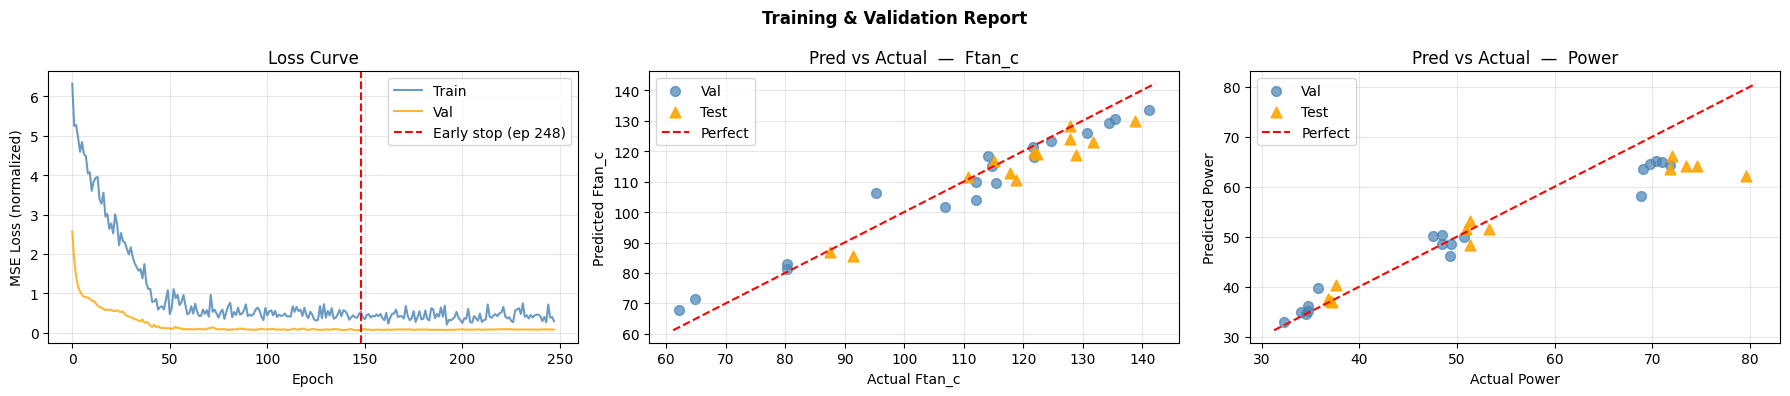

  Residuals
  ----------------------------------------------------------
      Output |   Set |     Bias |      Std |  Max Err
  ----------------------------------------------------------
      Ftan_c |   Val |  -0.9575 |   5.1853 |  10.8815
      Ftan_c |  Test |  -4.1150 |   3.8691 |  10.2579
       Power |   Val |  -1.8370 |   3.8571 |  10.6066
       Power |  Test |  -3.8936 |   5.7653 |  17.4170
  ----------------------------------------------------------


In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Training & Validation Loss', fontweight='bold')
ax.plot(train_loss_hist, label='Train', color='steelblue', alpha=0.8)
ax.plot(val_loss_hist,   label='Val',   color='orange',    alpha=0.8)
ax.axvline(stopped_epoch - patience, color='red', linestyle='--',
           label=f'Early stop (ep {stopped_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (normalised)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Force predictions scatter ──────────────────────────────────────────────────
n_f = len(force_cols)
fig, axes = plt.subplots(2, (n_f + 1) // 2, figsize=(5 * ((n_f + 1) // 2), 9))
fig.suptitle('Force predictions — val vs test', fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(force_cols):
    ax = axes[i]
    ax.scatter(tf_val_w[:, i], pf_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(tf_te_w[:,  i], pf_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(tf_val_w[:, i].min(), tf_te_w[:, i].min()) - 1
    hi = max(tf_val_w[:, i].max(), tf_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for ax in axes[n_f:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('force_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fatigue predictions scatter ────────────────────────────────────────────────
n_a = len(fatigue_cols)
fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 4))
fig.suptitle('Fatigue life predictions — val vs test', fontweight='bold')
for i, col in enumerate(fatigue_cols):
    ax = axes[i]
    ax.scatter(ta_val_w[:, i], pa_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(ta_te_w[:,  i], pa_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(ta_val_w[:, i].min(), ta_te_w[:, i].min()) - 1
    hi = max(ta_val_w[:, i].max(), ta_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fatigue_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Residual table ─────────────────────────────────────────────────────────────
print('  Residuals')
print('  ' + '-'*65)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-'*65)
for group_name, cols, pv, tv, pt, tt in [
    ('Forces',  force_cols,   pf_val_w, tf_val_w, pf_te_w, tf_te_w),
    ('Fatigue', fatigue_cols, pa_val_w, ta_val_w, pa_te_w, ta_te_w),
]:
    print(f'  --- {group_name} ---')
    for i, col in enumerate(cols):
        for label, yp, yt in [('Val', pv, tv), ('Test', pt, tt)]:
            err = yp[:, i] - yt[:, i]
            print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
                  f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-'*65)


In [ ]:
# ── Correlation diagnostics ───────────────────────────────────────────────────
print("Force–fatigue cross-correlation (mean abs):")
cross = torch.corrcoef(torch.cat([yf, ya], dim=1).T)
fc = cross[:n_force, n_force:]   # n_force × n_fatigue
print(f"  Mean |r| force→fatigue : {fc.abs().mean():.4f}")
print(f"  Max  |r| force→fatigue : {fc.abs().max():.4f}")

print("\nForce output std (should all be > 0):")
print(yf.std(dim=0).numpy().round(4))

print("\nFatigue output std (should all be > 0):")
print(ya.std(dim=0).numpy().round(4))

print("\nFatigue output mean (check scale — consider log-transform if > 1e4):")
print(ya.mean(dim=0).numpy().round(2))


Ftan_c vs Power correlation: 0.6940

Ftan_c
  Train : [52.46, 140.19]
  Val   : [62.20, 141.13]
  Test  : [87.55, 138.74]

Power
  Train : [10.77, 67.43]
  Val   : [32.27, 71.79]
  Test  : [36.82, 79.60]


In [ ]:
# ── Auto-read run number ──────────────────────────────────────────────────────
log_file   = 'experiment_log.csv'
run_number = 0
if os.path.isfile(log_file):
    with open(log_file, 'r') as f:
        run_number = sum(1 for line in f) - 1

# ── Auto-detect config ─────────────────────────────────────────────────────────
dropout_val = 0.0
for module in force_model.modules():
    if isinstance(module, nn.Dropout):
        dropout_val = module.p; break

block_layers = [type(m).__name__ for m in force_model.block1]
block_str    = ' -> '.join(block_layers)

n_params_force   = sum(p.numel() for p in force_model.parameters())
n_params_fatigue = sum(p.numel() for p in fatigue_model.parameters())

run_config = {
    'run_number'      : run_number + 1,
    'timestamp'       : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'block'           : block_str,
    'n_params_force'  : n_params_force,
    'n_params_fatigue': n_params_fatigue,
    'dropout'         : dropout_val,
    'lambda_pinn'     : Lambda,
    'CHECK'           : str(CHECK),
    'epochs_max'      : epochs,
    'stopped_epoch'   : stopped_epoch,
    'best_val_loss'   : round(best_val_loss, 6),
    'patience'        : patience,
    'batch_size'      : batch_size,
    'alpha_mixup'     : alpha,
    'n_force_outputs' : n_force,
    'n_fatigue_outputs': n_fatigue,
    'seed'            : seed,
    'n_total'         : len(x),
    'n_train'         : len(train_idx),
    'n_val'           : len(val_idx),
    'n_test'          : len(test_idx),
    'pct_train'       : round(len(train_idx)/len(x)*100, 1),
    'pct_val'         : round(len(val_idx)/len(x)*100,   1),
    'pct_test'        : round(len(test_idx)/len(x)*100,  1),
}

run_metrics = {}
for col in force_cols:
    for split, res in [('val', val_force_res), ('test', test_force_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)
for col in fatigue_cols:
    for split, res in [('val', val_fat_res), ('test', test_fat_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)

row = {**run_config, **run_metrics}
file_exists = os.path.isfile(log_file)
with open(log_file, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

# ── Summary print ──────────────────────────────────────────────────────────────
print('=' * 62)
print(f'  Run {run_config["run_number"]} logged -> {log_file}')
print('=' * 62)
print(f'  Block         : {block_str}')
print(f'  Dropout       : {dropout_val}')
print(f'  Lambda        : {Lambda}')
print(f'  Physics check : {CHECK}')
print(f'  Params Force  : {n_params_force}')
print(f'  Params Fatigue: {n_params_fatigue}')
print(f'  Stopped       : epoch {stopped_epoch} / {epochs}')
print(f'  Best val      : {best_val_loss:.6f}')
print('-' * 62)
print(f'  {"Output":>10} | {"Val MAE":>8} | {"Val R2":>7} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>10} | {run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>10} | {run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print('=' * 62)


  Run 67 logged -> experiment_log.csv
  Block      : Linear -> LayerNorm -> Sigmoid -> Dropout
  Dropout    : 0.0
  Lambda     : 0.5
  Physics Formula      : ['Torque']
  Parameters : 5218
  Seed       : 42
  Outputs    : 2  ['Ftan_c', 'Power']
  Split      : 69.0% train / 18.0% val / 13.0% test (69 / 18 / 13 samples)
  Stopped    : epoch 248 / 600
  Best val   : 0.059984
--------------------------------------------------------------
      Output |  Val MAE |  Val R2 |  Test MAE |  Test R2 |  Test Bias |  Test Std
  --------------------------------------------------------------------------------
      Ftan_c |   4.4826 |  0.9474 |    4.5606 |   0.8442 |    -4.1150 |    3.8691
       Power |   3.1399 |  0.9158 |    4.8182 |   0.8039 |    -3.8936 |    5.7653
  Total runs logged : 67
